In [1]:
## -- Check for 3rd party libraries --
try:
    import pytabkit
    import skrub
    import shap
    import xgboost as xgb
except:
    %pip install -q pytabkit
    %pip install -q skrub
    %pip install -q shap
    %pip install -q xgboost

    import pytabkit
    import skrub
    import shap
    import xgboost as xgb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

# if torch.cuda.is_available():
#     # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
#     # get_ipython().run_line_magic('load_ext', 'cuml.accel')
#     from cuml.preprocessing import TargetEncoder as cuTE
# else:
#     pass

ℹ️ Running on Cuda: True


In [3]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
from skrub import TableVectorizer
from pytabkit import (
        RealMLP_TD_Classifier,
        TabM_D_Classifier,
        XGB_TD_Classifier,
        LGBM_TD_Classifier,
        CatBoost_TD_Classifier,
)
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.calibration import CalibrationDisplay

import warnings

print('📚 Libraries imported')

2026-02-28 21:16:42.874961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772313403.055861      33 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772313403.107072      33 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772313403.555342      33 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772313403.555386      33 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772313403.555389      33 computation_placer.cc:177] computation placer alr

📚 Libraries imported


In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'
RED    = '\033[31m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET} {RED} RED {RESET}")

CLASSIC  GREEN   YELLOW   RED 


In [5]:
# # -- Load Colab Data --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e2/'

submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/myheart-disease-dataset/'
orig = pd.read_csv(ORIG_PATH+'Heart_Disease_Prediction.csv')

## -- Remove trailing spaces in column names --
for col in test.columns:
    n = col.replace(' ', '_') #.lower()
    print(f"Removing spaces in {col} to {n}")
    train.rename(columns={col: n}, inplace=True)
    test.rename(columns={col: n}, inplace=True)
    orig.rename(columns={col: n}, inplace=True)
    
TARGET = train.columns[-1]
NUMS   = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
CATS   = [c for c in train.columns if c not in [TARGET]+NUMS] 

BASE = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Presence': 1, 'Absence': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Removing spaces in Age to Age
Removing spaces in Sex to Sex
Removing spaces in Chest pain type to Chest_pain_type
Removing spaces in BP to BP
Removing spaces in Cholesterol to Cholesterol
Removing spaces in FBS over 120 to FBS_over_120
Removing spaces in EKG results to EKG_results
Removing spaces in Max HR to Max_HR
Removing spaces in Exercise angina to Exercise_angina
Removing spaces in ST depression to ST_depression
Removing spaces in Slope of ST to Slope_of_ST
Removing spaces in Number of vessels fluro to Number_of_vessels_fluro
Removing spaces in Thallium to Thallium
Train shape: (630000, 14)
Test shape: (270000, 13)
Original shape: (270, 14)

Total Numerical: 5
Total Categorical: 8
Total base features: 13


In [7]:
display(train.head())
train.info()

,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest_pain_type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS_over_120             630000 non-null  int64  
 6   EKG_results              630000 non-null  int64  
 7   Max_HR                   630000 non-null  int64  
 8   Exercise_angina          630000 non-null  int64  
 9   ST_depression            630000 non-null  float64
 10  Slope_of_ST              630000 non-null  int64  
 11  Number_of_vessels_fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  int64  
dtypes: f

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,Age,BP,Cholesterol,Max_HR,ST_depression,Sex,Chest_pain_type,FBS_over_120,EKG_results,Exercise_angina,Slope_of_ST,Number_of_vessels_fluro,Thallium
Train,42,66,150,93,66,2,4,2,3,2,3,4,3
Original,41,47,144,90,39,2,4,2,3,2,3,4,3
Test,43,64,145,92,64,2,4,2,3,2,3,4,3


## FEATURE ENGINEERING

In [9]:
# ## -- Factorize using combined data --
# for c in CATS_2:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [11]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list = None,
    aggs: list = None,
    fill_nan: bool = False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"
            
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[TARGET].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[TARGET].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[TARGET].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[TARGET].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[TARGET].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[TARGET].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[TARGET].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[TARGET].mean()
    global_median = orig[TARGET].median()
    
    def fill_conditionally(df1):
        df = df1.copy()
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [12]:
# train, test, _, NEW_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.sample(1000),
#     features=BASE,
#     ## --- (count, mean, count, std, nunique, median, max, min)
#     aggs=['mean', 'count', 'std'],
#     fill_nan=True,
# )

# print(NEW_COLS)
# # train.isna().sum()

In [13]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 13


,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0


# ML TRAINING

In [14]:

tabm_params = {
    'arch_type': 'tabm-normal',
    'num_emb_type': 'pwl',
    # 'allow_amp': True,
    'lr': 0.002,
    # 'batch_size': 256,
    'n_epochs': 20,
    'patience': 4,
    'n_blocks': 3,
    # 'd_block': 512,
    'tabm_k': 24,
    # 'd_embedding': 16,
    # 'dropout': 0.1,
    # 'gradient_clipping_norm': None,
    # 'num_emb_n_bins': 48,
    # 'weight_decay': 0.01,
    'random_state': SEED,
    'verbosity': 2,
    'val_metric_name': '1-auc_ovr',
}

xgb_params = {
    # 'grow_policy': 'depthwise', #'lossguide',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.01,
    'max_depth': 2,
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'reg_lambda': 1.0,
    'reg_alpha': 3.0,
    # 'min_child_weight': 5,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}


##### FOLD 1/15


TE_merging:   0%|          | 0/13 [00:00<?, ?it/s]

CategoryMeanEncoding: 5 | 
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression', 'OTE_Age_mean', 'OTE_Age_count', 'OTE_Age_std', 'OTE_BP_mean', 'OTE_BP_count', 'OTE_BP_std', 'OTE_Cholesterol_mean', 'OTE_Cholesterol_count', 'OTE_Cholesterol_std', 'OTE_Max_HR_mean', 'OTE_Max_HR_count', 'OTE_Max_HR_std', 'OTE_ST_depression_mean', 'OTE_ST_depression_count', 'OTE_ST_depression_std', 'OTE_Sex_mean', 'OTE_Sex_count', 'OTE_Sex_std', 'OTE_Chest_pain_type_mean', 'OTE_Chest_pain_type_count', 'OTE_Chest_pain_type_std', 'OTE_FBS_over_120_mean', 'OTE_FBS_over_120_count', 'OTE_FBS_over_120_std', 'OTE_EKG_results_mean', 'OTE_EKG_results_count', 'OTE_EKG_results_std', 'OTE_Exercise_angina_mean', 'OTE_Exercise_angina_count', 'OTE_Exercise_angina_std', 'OTE_Slope_of_ST_mean', 'OTE_Slope_of_ST_count', 'OTE_Slope_of_ST_std', 'OTE_Number_of_vessels_fluro_mean', 'OTE_Number_of_vessels_fluro_count', 'OTE_Number_of_vessels_fluro_std', 'OTE_Thallium_mean', 'OTE_Thallium_count

Epoch 0: 100%|██████████| 2297/2297 [00:28<00:00, 80.33it/s]


(val) -0.0438
🌸 New best epoch! 🌸



...

(val) -0.0442



Epoch 7: 100%|██████████| 2297/2297 [00:28<00:00, 81.16it/s]


(val) -0.0446



Epoch 8: 100%|██████████| 2297/2297 [00:28<00:00, 81.21it/s]


(val) -0.0451


Result:
{'val': -0.04395771026611328, 'epoch': 3}
Restoring best model
	Model_1 AUC: 0.956042
[0]	train-auc:0.87931	valid-auc:0.87818
[1000]	train-auc:0.95469	valid-auc:0.95492
[2000]	train-auc:0.95577	valid-auc:0.95585
[3000]	train-auc:0.95596	valid-auc:0.95596
[3898]	train-auc:0.95604	valid-auc:0.95596
	Model_2 AUC: 0.955965
🔻 PseudoLabel Dropped: 0.956042 to 0.955965
| OOF AUC: 0.955718
| AVG AUC: 0.955727 ± 0.000652
| M_1 AUC: 0.955722 ± 0.000645


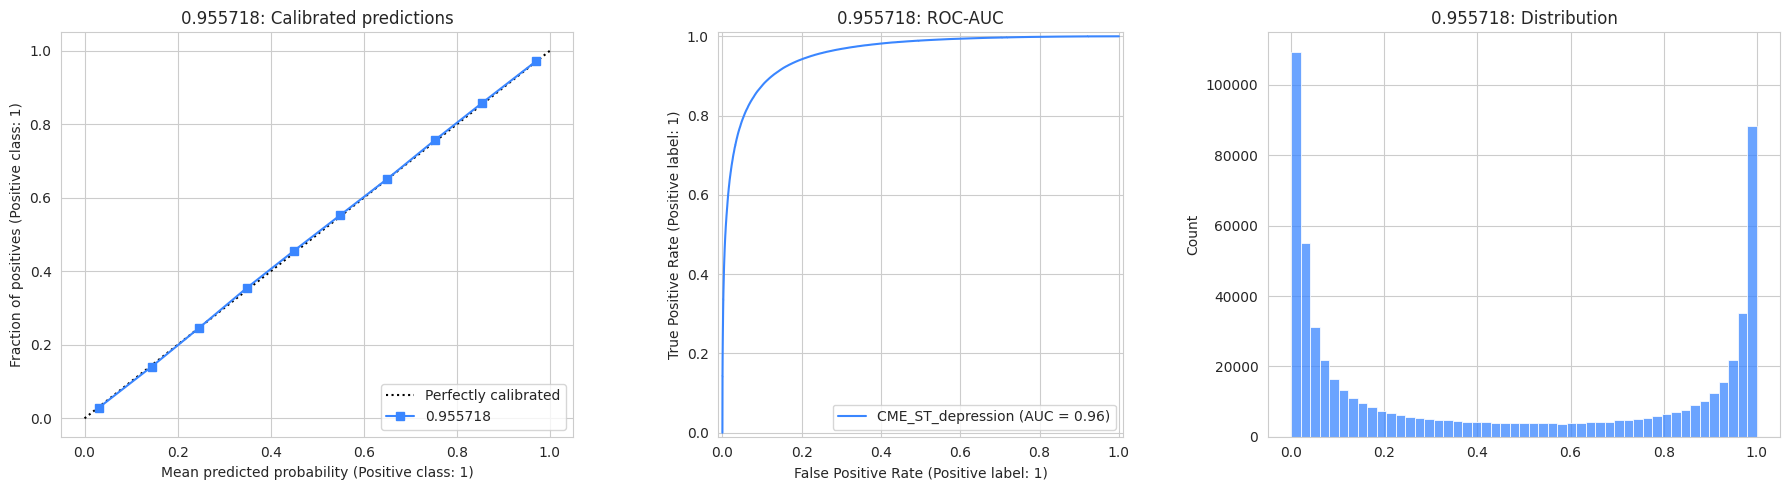


Training Time: 68.90 mins =========================


In [15]:
## -- DEFINE TRAINING PARAMETERS --

X = train[FEATURES] #.iloc[:100_000]
y = train[TARGET] #.iloc[:100_000]

N_SPLITS = 15
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []
m1_scores = []

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n{'#'*5} FOLD {fold+1}/{kf.n_splits}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    # ## -- OPTION A: Concatenate original data --
    # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
    # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
    # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    ## -- OPTION B: TE Merge original data --
    X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        orig,
        X_train,
        X_val,
        X_test,
        features=BASE,
        aggs=['mean', 'count', 'std'], # mean, median, count, std, nunique, max, min
        fill_nan=True,
    )

    # ## -- T.E FOR XGBOOST --
    # TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
    # X_train = TE.fit_transform(X_train, y_train)
    # X_val   = TE.transform(X_val)
    # X_test  = TE.transform(X_test)
    
    cme_features = NUMS 
    cme_cols = []
    print(f"CategoryMeanEncoding: {len(cme_features)} | ")
    for c in cme_features:
        n = f"CME_{c}"
        CME = CategoryMeanTransformer(cat_cols=[c])
        X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1)
        X_val[n]   = CME.transform(X_val[[c]]).fillna(-1)
        X_test[n]  = CME.transform(X_test[[c]]).fillna(-1)
        cme_cols.append(n)

    ## -- TABM: Stage 1 model --
    model_1 = TabM_D_Classifier(**tabm_params)
    # model_1 = RealMLP_TD_Regressor(random_state=SEED)
    
    model_1.fit(X_train, y_train, X_val, y_val, cat_col_names=CATS+cme_cols) 
    oof_m1 = model_1.predict_proba(X_val)[:, 1].ravel()
    test_m1 = model_1.predict_proba(X_test)[:, 1].ravel()

    score_m1 = roc_auc_score(y_val, oof_m1)
    print(f"{YELLOW}\tModel_1 AUC: {score_m1:.6f}{RESET}")
    m1_scores.append(score_m1)

    ## -- PSEUDO LABELS FROM model_1 AS FEATURES FOR model_2 --
    X_train_full = pd.concat([X_train, X_val, X_test], ignore_index=True).copy()
    y_train_full = np.concatenate([y_train.to_numpy(), oof_m1, test_m1], axis=0)

    for c in CATS+cme_cols:
        X_train_full[c] = X_train_full[c].astype(str).astype('category')

    X_val_2  = X_train_full.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test_2 = X_train_full.iloc[len(X_train)+len(X_val):]

    ## -- T.E FOR XGBOOST --
    TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
    X_train_full = TE.fit_transform(X_train_full, pd.Series(y_train_full, name=TARGET))
    X_val_2   = TE.transform(X_val_2)
    X_test_2  = TE.transform(X_test_2)

    dtrain = xgb.DMatrix(X_train_full, y_train_full, enable_categorical=True)
    dval   = xgb.DMatrix(X_val_2, y_val, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test_2, enable_categorical=True)

    model_2 = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round = 20_000,
        evals = [(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds = 300,
        verbose_eval = 1000,
    )

    oof_preds[val_idx] = model_2.predict(dval, iteration_range=(0, model_2.best_iteration+1)).ravel()
    score_m2 = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(score_m2)
    print(f"{YELLOW}\tModel_2 AUC: {score_m2:.6f}{RESET}")

    if score_m2 > score_m1:
        print(f"{GREEN}❇️ PseudoLabel Improved: {score_m1:.6f} to {score_m2:.6f}{RESET}")
    else:
        print(f"{RED}🔻 PseudoLabel Dropped: {score_m1:.6f} to {score_m2:.6f}{RESET}")

    test_preds += model_2.predict(dtest, iteration_range=(0, model_2.best_iteration+1)).ravel()

    gc.collect()
    torch.cuda.empty_cache()

## -- After all folds --
test_preds /= kf.n_splits

overall_score = np.round(roc_auc_score(y, oof_preds), 6)
print(f"{'='*50}{YELLOW}")
print(f"| OOF AUC: {overall_score}") 
print(f"| AVG AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{RESET}")
print(f"| M_1 AUC: {np.mean(m1_scores):.6f} ± {np.std(m1_scores):.6f}{RESET}")
print(f"{'='*50}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 3, figsize=(18, 5)) 

CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=overall_score, ax=axs[0])
axs[0].set_title(f"{overall_score}: Calibrated predictions")

RocCurveDisplay.from_predictions(y, oof_preds, name=n, ax=axs[1])
axs[1].set_title(f"{overall_score}: ROC-AUC")
# axs[1].grid(False)

sns.histplot(oof_preds, ax=axs[2])
axs[2].set_title(f"{overall_score}: Distribution")

plt.tight_layout()
plt.show()
print()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")

In [16]:
# ==================================================
# | OOF AUC: 0.95568
# | AVG AUC: 0.955684 ± 0.000466
# | M_1 AUC: 0.955673 ± 0.000468
# ==================================================
float(overall_score)

0.955718

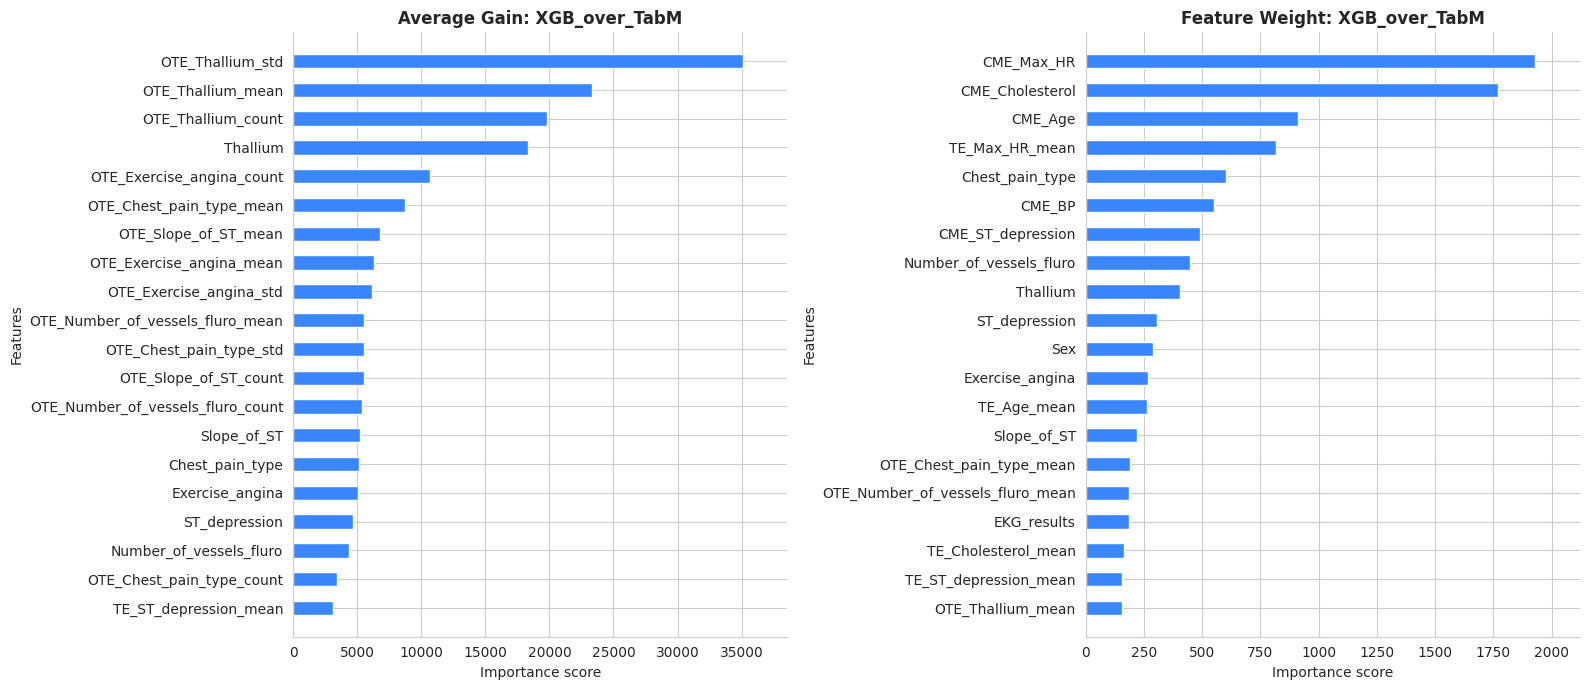

In [17]:
## -- Plot Feature Importances --
MAX = 20
_, axs = plt.subplots(1, 2, figsize=(16, 7))
xgb.plot_importance(
                    model_2, ax=axs[0],
                    max_num_features=MAX,
                    importance_type='gain',
                    height=0.5, show_values=False, #grid=False,
    )
axs[0].set_title('Average Gain: XGB_over_TabM', fontdict={'weight': 'bold'})

xgb.plot_importance(
                    model_2, ax=axs[1],
                    max_num_features=MAX,
                    importance_type='weight',
                    height=0.5, show_values=False, #grid=False,
    )
axs[1].set_title('Feature Weight: XGB_over_TabM', fontdict={'weight': 'bold'})

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## SUBMISSION

In [18]:
## -- SAVE OOF & PREDICTIONS --
name = f"xgb_tabM_pseudo_" + f"{overall_score}".split('.')[1]

pd.DataFrame(oof_preds, columns=[name]).to_parquet(f"oof_{name}.parquet", index=False)
pd.DataFrame(test_preds, columns=[name]).to_parquet(f"test_{name}.parquet", index=False)

## -- SUBMISSION --
submit[TARGET] = test_preds
submit.to_csv(f"submit_{name}.csv", index=False)
submit.head()

,id,Heart Disease
0,630000,0.941659
1,630001,0.009333
2,630002,0.990151
3,630003,0.004205
4,630004,0.192522
